<h1 align="center">HW2 · Denoise</h1>

---

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt


### 1. Загрузка исходной речи и шума, создание зашумлённого сигнала
---

In [2]:
clean_path = "audio/hello_world.wav"
noise_path = "audio/traffic-noise.wav"
noisy_path = "audio/hello_world_noisy.wav"

clean, sr_c = sf.read(clean_path)
noise, sr_n = sf.read(noise_path)

# в моно
if clean.ndim > 1:
    clean = clean.mean(axis=1)
if noise.ndim > 1:
    noise = noise.mean(axis=1)

clean = clean.astype(np.float32)
noise = noise.astype(np.float32)

# ресемплим шум под частоту речи
if sr_c != sr_n:
    print(f"resample noise: {sr_n} -> {sr_c}")
    t_old = np.linspace(0, len(noise) / sr_n, len(noise), endpoint=False)
    t_new = np.linspace(0, len(noise) / sr_n, int(len(noise) * sr_c / sr_n), endpoint=False)
    noise = np.interp(t_new, t_old, noise)
    sr_n = sr_c

# подгоняем длину шума под длину речи
if len(noise) < len(clean):
    reps = int(np.ceil(len(clean) / len(noise)))
    noise = np.tile(noise, reps)
noise = noise[:len(clean)]

# задаём SNR
target_snr_db = 0.0

Ps = np.mean(clean**2)
Pn = np.mean(noise**2)
alpha_snr = np.sqrt(Ps / (Pn * 10 ** (target_snr_db / 10)))

noise_scaled = noise * alpha_snr
noisy = clean + noise_scaled
noisy = np.clip(noisy, -1.0, 1.0)

sf.write(noisy_path, noisy, sr_c)

print("saved:", noisy_path)
print("sr:", sr_c, "len clean:", len(clean), "len noisy:", len(noisy))


resample noise: 44100 -> 48000
saved: audio/hello_world_noisy.wav
sr: 48000 len clean: 191488 len noisy: 191488


### 2. Функции для мел-спектрограммы
---

In [3]:
def hz_to_mel(f):
    return 2595.0 * np.log10(1.0 + f / 700.0)

def mel_to_hz(m):
    return 700.0 * (10.0**(m / 2595.0) - 1.0)

def compute_log_mel(
    y,
    sr,
    win_length_ms=25,
    hop_length_ms=10,
    n_fft=2048,
    n_mels=80,
    fmin=20.0,
    fmax=None,
    eps=1e-10,
):
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32)

    if fmax is None:
        fmax = sr / 2.0

    L = int(sr * win_length_ms / 1000)
    H = int(sr * hop_length_ms / 1000)

    num_frames = 1 + (len(y) - L) // H
    if num_frames <= 0:
        raise ValueError("Сигнал слишком короткий для заданных параметров окна и шага")

    w = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(L) / (L - 1))

    frames = np.zeros((num_frames, L), dtype=np.float32)
    for i in range(num_frames):
        start = i * H
        frames[i] = y[start:start + L] * w

    spec = np.fft.rfft(frames, n=n_fft, axis=1)
    power = (np.abs(spec) ** 2) / n_fft

    K = n_fft // 2 + 1
    freqs = np.linspace(0.0, sr / 2.0, K)

    m_min = hz_to_mel(fmin)
    m_max = hz_to_mel(fmax)
    mel_points = np.linspace(m_min, m_max, n_mels + 2)
    hz_points = mel_to_hz(mel_points)

    H_mel = np.zeros((n_mels, K), dtype=np.float32)
    for i in range(1, n_mels + 1):
        f_l, f_c, f_r = hz_points[i-1], hz_points[i], hz_points[i+1]
        left = (freqs - f_l) / (f_c - f_l)
        right = (f_r - freqs) / (f_r - f_c)
        tri = np.maximum(0.0, np.minimum(left, right))
        H_mel[i-1] = tri

    S_mel = H_mel @ power.T
    S_mel_db = 10 * np.log10(S_mel + eps)

    return S_mel_db

def compute_log_mel_from_file(path, **kwargs):
    y, sr = sf.read(path)
    S = compute_log_mel(y, sr, **kwargs)
    return S, sr


### 4. STFT и iSTFT для спектрального вычитания
---

In [4]:
def stft(y, sr, win_length_ms=25, hop_length_ms=10, n_fft=2048):
    if y.ndim > 1:
        y = y.mean(axis=1)
    y = y.astype(np.float32)

    L = int(sr * win_length_ms / 1000)
    H = int(sr * hop_length_ms / 1000)

    w = 0.5 - 0.5 * np.cos(2 * np.pi * np.arange(L) / (L - 1))

    num_frames = 1 + (len(y) - L) // H
    if num_frames <= 0:
        raise ValueError("Сигнал слишком короткий для заданных параметров окна и шага")

    frames = np.zeros((num_frames, L), dtype=np.float32)
    for i in range(num_frames):
        start = i * H
        frames[i] = y[start:start + L] * w

    spec = np.fft.rfft(frames, n=n_fft, axis=1)
    return spec, w, L, H

def istft(spec, w, H, L):
    num_frames = spec.shape[0]
    n_fft = (spec.shape[1] - 1) * 2

    out_len = L + (num_frames - 1) * H
    y_rec = np.zeros(out_len, dtype=np.float32)
    norm = np.zeros(out_len, dtype=np.float32)

    for i in range(num_frames):
        frame_spec = spec[i]
        frame_time = np.fft.irfft(frame_spec, n=n_fft).astype(np.float32)
        frame_time = frame_time[:L]

        start = i * H
        y_rec[start:start + L] += frame_time * w
        norm[start:start + L] += w**2

    y_rec = np.divide(
        y_rec,
        norm + 1e-8,
        out=np.zeros_like(y_rec),
        where=norm > 1e-8
    )

    return y_rec


### 5. Спектральное вычитание
---

In [5]:
def spectral_subtraction(
    noisy,
    sr,
    win_length_ms=25,
    hop_length_ms=10,
    n_fft=2048,
    alpha=2.0,
    beta=0.05,
    noise_percentile=30,
):
    # STFT зашумлённого сигнала
    spec_noisy, w, L, H = stft(noisy, sr, win_length_ms, hop_length_ms, n_fft)
    mag_noisy = np.abs(spec_noisy)
    phase_noisy = np.angle(spec_noisy)

    # перцентиль по времени для каждой частоты
    noise_mag_mean = np.percentile(mag_noisy, q=noise_percentile, axis=0)  
    noise_mag_mean = np.maximum(noise_mag_mean, 1e-8)

    # --- Спектральное вычитание ---
    mag_clean = mag_noisy - alpha * noise_mag_mean[None, :]
    mag_clean = np.maximum(mag_clean, beta * noise_mag_mean[None, :])

    spec_clean = mag_clean * np.exp(1j * phase_noisy)

    # Обратно во временную область
    y_clean = istft(spec_clean, w, H, L)
    return y_clean


denoised = spectral_subtraction(
    noisy=noisy,
    sr=sr_c,
    alpha=2.0,
    beta=0.05,
)

denoised = np.clip(denoised, -1.0, 1.0)
denoised_path = "audio/hello_world_denoised.wav"
sf.write(denoised_path, denoised, sr_c)


### 6. Мел-спектрограммы
---

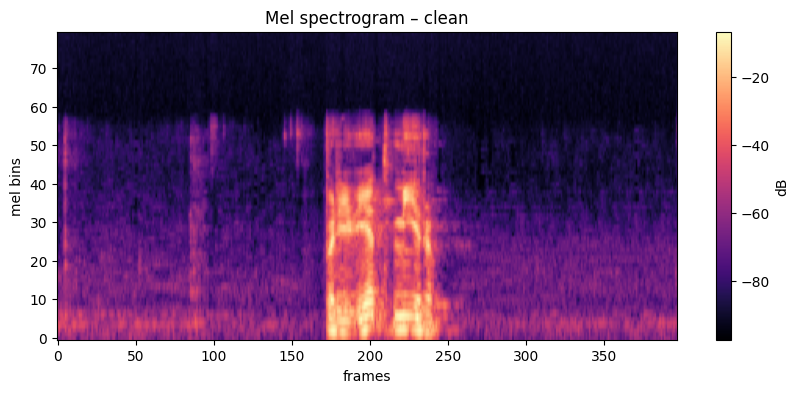

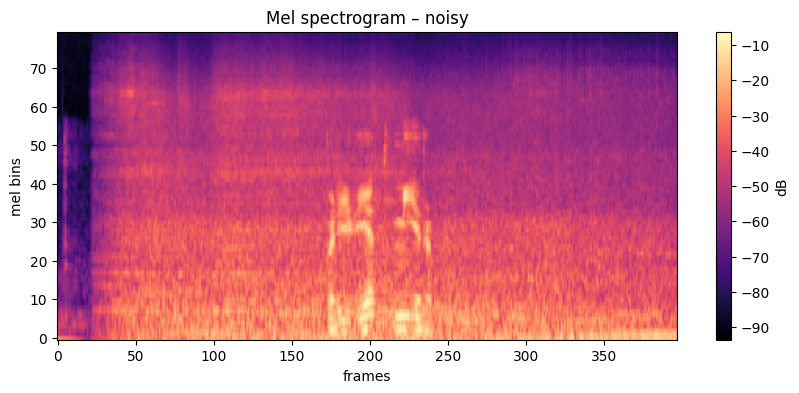

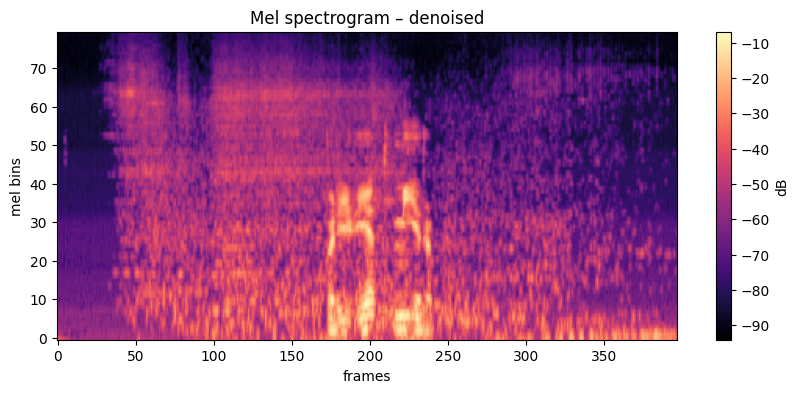

In [6]:
S_denoised, sr = compute_log_mel_from_file(denoised_path)
S_clean, sr = compute_log_mel_from_file(clean_path)
S_noisy, sr = compute_log_mel_from_file(noisy_path)

plt.figure(figsize=(10, 4))
plt.imshow(S_clean, origin="lower", aspect="auto", cmap="magma")
plt.colorbar(label="dB")
plt.title("Mel spectrogram – clean")
plt.xlabel("frames")
plt.ylabel("mel bins")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(S_noisy, origin="lower", aspect="auto", cmap="magma")
plt.colorbar(label="dB")
plt.title("Mel spectrogram – noisy")
plt.xlabel("frames")
plt.ylabel("mel bins")
plt.show()

plt.figure(figsize=(10, 4))
plt.imshow(S_denoised, origin="lower", aspect="auto", cmap="magma")
plt.colorbar(label="dB")
plt.title("Mel spectrogram – denoised")
plt.xlabel("frames")
plt.ylabel("mel bins")
plt.show()



### 7. Метрики: SNR и SI-SNR до и после
---

In [7]:
def snr_metric(clean, processed):
    eps = 1e-8
    clean = clean.astype(np.float32)
    processed = processed.astype(np.float32)
    e = clean - processed
    return 10 * np.log10((np.sum(clean**2) + eps) / (np.sum(e**2) + eps))

def si_snr_metric(clean, est):
    eps = 1e-8
    clean = clean.astype(np.float32)
    est = est.astype(np.float32)

    clean = clean - clean.mean()
    est = est - est.mean()

    dot = np.sum(est * clean)
    s_target = dot * clean / (np.sum(clean**2) + eps)
    e_noise = est - s_target

    return 10 * np.log10(np.sum(s_target**2) / (np.sum(e_noise**2) + eps))

min_len = min(len(clean), len(noisy), len(denoised))
c = clean[:min_len]
n = noisy[:min_len]
d = denoised[:min_len]

print("SNR noisy   :", snr_metric(c, n))
print("SNR denoised:", snr_metric(c, d))
print("SI-SNR noisy   :", si_snr_metric(c, n))
print("SI-SNR denoised:", si_snr_metric(c, d))


SNR noisy   : 0.009592126457118011
SNR denoised: 2.5972240999056497
SI-SNR noisy   : 0.2951977209640679
SI-SNR denoised: 1.1808168315611407


### P.S. Подбор оптимальных параметров для спектрального вычитания
---

In [8]:
alphas = [0.5, 0.8, 1.0, 1.2, 2.0]
betas  = [0.01, 0.05, 0.1]

results = []

for a in alphas:
    for b in betas:
        den = spectral_subtraction(
            noisy=noisy,
            sr=sr_c,
            alpha=a,
            beta=b,
        )
        den = np.clip(den, -1.0, 1.0)

        min_len = min(len(clean), len(noisy), len(den))
        c = clean[:min_len]
        n = noisy[:min_len]
        d = den[:min_len]

        snr_n  = snr_metric(c, n)
        snr_d  = snr_metric(c, d)
        sisnr_n = si_snr_metric(c, n)
        sisnr_d = si_snr_metric(c, d)

        results.append((a, b, snr_d, sisnr_d))
        print(f"alpha={a:.2f}, beta={b:.3f} -> SNR_denoised={snr_d:.3f} dB, SI-SNR_denoised={sisnr_d:.3f} dB")


alpha=0.50, beta=0.010 -> SNR_denoised=-0.299 dB, SI-SNR_denoised=-0.483 dB
alpha=0.50, beta=0.050 -> SNR_denoised=-0.237 dB, SI-SNR_denoised=-0.420 dB
alpha=0.50, beta=0.100 -> SNR_denoised=-0.170 dB, SI-SNR_denoised=-0.351 dB
alpha=0.80, beta=0.010 -> SNR_denoised=-0.118 dB, SI-SNR_denoised=-0.576 dB
alpha=0.80, beta=0.050 -> SNR_denoised=-0.116 dB, SI-SNR_denoised=-0.574 dB
alpha=0.80, beta=0.100 -> SNR_denoised=-0.111 dB, SI-SNR_denoised=-0.567 dB
alpha=1.00, beta=0.010 -> SNR_denoised=-0.145 dB, SI-SNR_denoised=-0.786 dB
alpha=1.00, beta=0.050 -> SNR_denoised=-0.046 dB, SI-SNR_denoised=-0.684 dB
alpha=1.00, beta=0.100 -> SNR_denoised=0.107 dB, SI-SNR_denoised=-0.529 dB
alpha=1.20, beta=0.010 -> SNR_denoised=0.282 dB, SI-SNR_denoised=-0.535 dB
alpha=1.20, beta=0.050 -> SNR_denoised=0.445 dB, SI-SNR_denoised=-0.369 dB
alpha=1.20, beta=0.100 -> SNR_denoised=0.677 dB, SI-SNR_denoised=-0.133 dB
alpha=2.00, beta=0.010 -> SNR_denoised=2.491 dB, SI-SNR_denoised=1.066 dB
alpha=2.00, beta=0